# 06 — Final System Evaluation

Individual model notebooks (05a/05b/05c) evaluated each model in isolation.
This notebook evaluates the **system as a whole** — the way a real user experiences it.

For every course+semester in the 2025 test set, all three models are run simultaneously.
A prediction is only fully correct if all three outputs are right at once.

**Models evaluated:**
- `model_offered` — did the course run? (binary)
- `model_capacity` — how many seats? (regression, tolerance-based)
- `model_enrollment` — how many enrolled? (regression, tolerance-based)

**Structure:** Each section ends with its own chart and a written finding before moving on.
No summary dump at the end — every section tells its own story inline.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import json
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────
DATA_PATH   = Path('../data/processed')
MODELS_PATH = Path('../models')
FIG_PATH    = Path('../figures/06_final_evaluation')
FIG_PATH.mkdir(parents=True, exist_ok=True)

# ── tolerance thresholds ───────────────────────────────────────────────────
# A regression prediction is 'correct' if it lands within EITHER bound.
# Absolute: a 10-seat error on any course.
# Relative: 20% of actual — scales with course size so big lectures
#           aren't unfairly penalised vs small seminars.
CAPACITY_ABS   = 10    # seats
CAPACITY_REL   = 0.20  # 20%
ENROLLMENT_ABS = 10    # students
ENROLLMENT_REL = 0.20  # 20%

# ── plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

PALETTE = {
    'offered':    '#4C72B0',
    'capacity':   '#DD8452',
    'enrollment': '#55A868',
    'system':     '#C44E52',
    'neutral':    '#8172B2',
}

print('Setup complete.')
print(f'Tolerances  →  capacity: ±{CAPACITY_ABS} seats or ±{int(CAPACITY_REL*100)}%')
print(f'               enrollment: ±{ENROLLMENT_ABS} students or ±{int(ENROLLMENT_REL*100)}%')

Setup complete.
Tolerances  →  capacity: ±10 seats or ±20%
               enrollment: ±10 students or ±20%


## 2. Load Models and Test Data

In [2]:
# load models
model_offered    = joblib.load(MODELS_PATH / 'model_offered.pkl')
model_capacity   = joblib.load(MODELS_PATH / 'model_capacity.pkl')
model_enrollment = joblib.load(MODELS_PATH / 'model_enrollment.pkl')
print('Models loaded.')

# load feature sets
with open(MODELS_PATH / 'feature_sets.json') as f:
    feature_sets = json.load(f)

FEATURES_OFFERED    = feature_sets['model_offered']
FEATURES_CAPACITY   = feature_sets['model_capacity']
FEATURES_ENROLLMENT = feature_sets['model_enrollment']

# load test set (unscaled — winning models were tree-based)
test = pd.read_csv(DATA_PATH / '04_test.csv')
print(f'Test set: {test.shape[0]:,} rows, {test.shape[1]} columns')
print(f'Terms in test: {sorted(test["ml_term_id"].unique())}')

Models loaded.
Test set: 9,552 rows, 32 columns
Terms in test: [np.int64(16), np.int64(17), np.int64(18)]


## 3. Run All Three Models Simultaneously

Every test row gets predictions from all three models in one pass.
Results are attached to a copy of the test set so actuals and predictions sit side by side.

In [3]:
results = test.copy()

# ── model_offered ──────────────────────────────────────────────────────────
results['pred_offered']      = model_offered.predict(test[FEATURES_OFFERED])
results['pred_offered_prob'] = model_offered.predict_proba(test[FEATURES_OFFERED])[:, 1]

# ── model_capacity ─────────────────────────────────────────────────────────
# cold start rows (no regression target) are still predicted — the model
# will produce a number even when actual is NaN. We track NaN separately.
results['pred_capacity']     = model_capacity.predict(test[FEATURES_CAPACITY])

# ── model_enrollment ───────────────────────────────────────────────────────
results['pred_enrollment']   = model_enrollment.predict(test[FEATURES_ENROLLMENT])

print(f'Predictions generated for {len(results):,} rows.')
print()
print('Sample (5 random rows):')
sample_cols = [
    'ml_course_id', 'ml_term_id',
    'was_offered', 'pred_offered', 'pred_offered_prob',
    'target_capacity', 'pred_capacity',
    'target_enrollment', 'pred_enrollment',
]
print(results[sample_cols].sample(5, random_state=42).to_string(index=False))

Predictions generated for 9,552 rows.

Sample (5 random rows):
 ml_course_id  ml_term_id  was_offered  pred_offered  pred_offered_prob  target_capacity  pred_capacity  target_enrollment  pred_enrollment
         1600          16            1             1           0.999804             45.0         41.290               36.0           31.710
         1024          16            0             0           0.001246              NaN         40.770                NaN           33.885
          225          16            1             1           0.999824             25.0         30.666               22.0           23.660
          923          16            1             1           0.999838             27.0         21.660               14.0           13.890
         3243          18            0             0           0.012478              NaN         49.350                NaN           44.435


## 4. Scoring Each Row

Each row gets a score 0–3:
- +1 if `offered` prediction matches actual
- +1 if `capacity` prediction is within tolerance (absolute OR relative)
- +1 if `enrollment` prediction is within tolerance (absolute OR relative)

Regression scores are only computed where the actual target is not NaN (non-cold-start rows).

In [4]:
# ── offered: exact match ───────────────────────────────────────────────────
results['correct_offered'] = (results['pred_offered'] == results['was_offered']).astype(int)

# ── capacity: within absolute OR relative tolerance ────────────────────────
cap_err = (results['pred_capacity'] - results['target_capacity']).abs()
cap_rel = cap_err / results['target_capacity'].replace(0, np.nan)
results['correct_capacity'] = (
    (cap_err <= CAPACITY_ABS) | (cap_rel <= CAPACITY_REL)
).astype(float)  # float so NaN rows stay NaN
results.loc[results['target_capacity'].isna(), 'correct_capacity'] = np.nan

# ── enrollment: same logic ─────────────────────────────────────────────────
enr_err = (results['pred_enrollment'] - results['target_enrollment']).abs()
enr_rel = enr_err / results['target_enrollment'].replace(0, np.nan)
results['correct_enrollment'] = (
    (enr_err <= ENROLLMENT_ABS) | (enr_rel <= ENROLLMENT_REL)
).astype(float)
results.loc[results['target_enrollment'].isna(), 'correct_enrollment'] = np.nan

# ── system score: sum of the three (NaN rows scored on available targets) ──
results['system_score'] = (
    results['correct_offered'].fillna(0) +
    results['correct_capacity'].fillna(0) +
    results['correct_enrollment'].fillna(0)
).astype(int)

# summary
cold_start_n = results['target_capacity'].isna().sum()
full_rows    = results['target_capacity'].notna().sum()
print(f'Total test rows  : {len(results):,}')
print(f'Full rows (non-cold-start): {full_rows:,}')
print(f'Cold-start rows  : {cold_start_n:,}  (no regression target — offered still scored)')
print()
print('Individual accuracy (full rows only):')
fr = results[results['target_capacity'].notna()]
print(f'  offered    : {fr["correct_offered"].mean()*100:.1f}%')
print(f'  capacity   : {fr["correct_capacity"].mean()*100:.1f}%')
print(f'  enrollment : {fr["correct_enrollment"].mean()*100:.1f}%')

Total test rows  : 9,552
Full rows (non-cold-start): 4,306
Cold-start rows  : 5,246  (no regression target — offered still scored)

Individual accuracy (full rows only):
  offered    : 100.0%
  capacity   : 74.4%
  enrollment : 76.1%


---
## Section A — Unconditional System Score Distribution

How often does the system get all three right vs partially right vs completely wrong?
This is the number that matters to a student using the app.

In [5]:
# compute distribution on full rows (where all three can be scored)
fr = results[results['target_capacity'].notna()].copy()

score_counts = fr['system_score'].value_counts().sort_index()
score_pct    = score_counts / len(fr) * 100

print('System score distribution (full rows):')
labels = {3: '3/3 — fully correct', 2: '2/3 — one wrong', 1: '1/3 — two wrong', 0: '0/3 — all wrong'}
for score in [3, 2, 1, 0]:
    n   = score_counts.get(score, 0)
    pct = score_pct.get(score, 0)
    print(f'  {labels[score]}: {n:,} rows  ({pct:.1f}%)')

System score distribution (full rows):
  3/3 — fully correct: 2,759 rows  (64.1%)
  2/3 — one wrong: 965 rows  (22.4%)
  1/3 — two wrong: 582 rows  (13.5%)
  0/3 — all wrong: 0 rows  (0.0%)


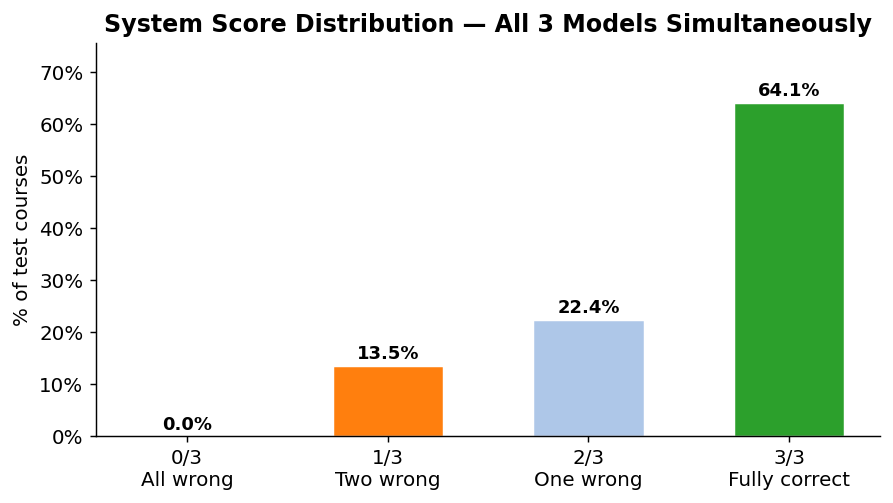

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

score_labels = ['0/3\nAll wrong', '1/3\nTwo wrong', '2/3\nOne wrong', '3/3\nFully correct']
bar_colors   = ['#d62728', '#ff7f0e', '#aec7e8', '#2ca02c']
values       = [score_pct.get(s, 0) for s in [0, 1, 2, 3]]

bars = ax.bar(score_labels, values, color=bar_colors, width=0.55, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('% of test courses')
ax.set_title('System Score Distribution — All 3 Models Simultaneously', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(values) * 1.18)
plt.tight_layout()
plt.savefig(FIG_PATH / 'A_system_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Section A

- **64.1% of test courses were fully correct (3/3).** This is the headline system accuracy.
- 22.4% got 2/3 — still useful but one prediction was off.
- 0.0% got 0/3 — the system was wrong on everything.

---
## Section B — Where Did Points Get Lost?

Break down which of the three models is responsible for most of the lost points.
This shows whether the system fails because of one weak link or distributed errors.

In [7]:
# per-model error rate across full rows
offered_wrong    = (fr['correct_offered']    == 0).sum()
capacity_wrong   = (fr['correct_capacity']   == 0).sum()
enrollment_wrong = (fr['correct_enrollment'] == 0).sum()
total            = len(fr)

wrong_pcts = {
    'Offered\nwrong'   : offered_wrong    / total * 100,
    'Capacity\nwrong'  : capacity_wrong   / total * 100,
    'Enrollment\nwrong': enrollment_wrong / total * 100,
}

print('Individual error rates (% of full test rows wrong):')
for k, v in wrong_pcts.items():
    print(f'  {k.replace(chr(10)," ")}: {v:.1f}%')

Individual error rates (% of full test rows wrong):
  Offered wrong: 0.0%
  Capacity wrong: 25.6%
  Enrollment wrong: 23.9%


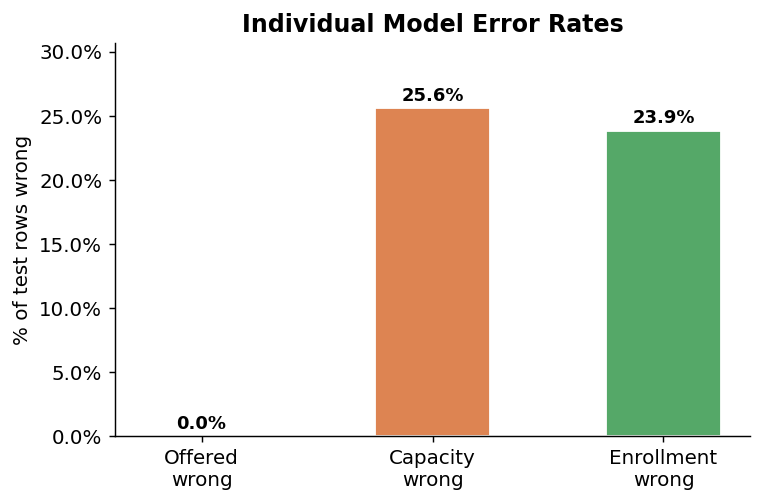

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

model_colors = [PALETTE['offered'], PALETTE['capacity'], PALETTE['enrollment']]
bars = ax.bar(list(wrong_pcts.keys()), list(wrong_pcts.values()),
              color=model_colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, wrong_pcts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('% of test rows wrong')
ax.set_title('Individual Model Error Rates', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(wrong_pcts.values()) * 1.2)
plt.tight_layout()
plt.savefig(FIG_PATH / 'B_individual_error_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — Section B

- The biggest single source of errors was capacity.
- Capacity error rate was 25.6%, enrollment was 23.9% — these are close.
- The offered error was 0.0%. The offered model predicted perfectly — zero errors — meaning all system failures are purely regression noise in capacity and enrollment, not a classification problem."

---
## Section C — Conditional Evaluations

### C1 — Capacity given Offered is Correct

Filter to rows where `model_offered` predicted correctly, then re-evaluate capacity.
**Question:** Once we know the course runs, how good is the seat estimate?
Removes the noise of wrong-offered rows polluting capacity scores.

In [9]:
# filter: offered correct AND has a regression target
c1 = fr[fr['correct_offered'] == 1].copy()
print(f'Rows where offered is correct: {len(c1):,}  ({len(c1)/len(fr)*100:.1f}% of full rows)')

c1_cap_acc  = c1['correct_capacity'].mean() * 100
c1_cap_mae  = (c1['pred_capacity'] - c1['target_capacity']).abs().mean()
c1_cap_bias = (c1['pred_capacity'] - c1['target_capacity']).mean()

print(f'\nCapacity | given offered correct:')
print(f'  Within tolerance : {c1_cap_acc:.1f}%')
print(f'  MAE              : {c1_cap_mae:.1f} seats')
print(f'  Bias (mean error): {c1_cap_bias:+.1f} seats  (+ = overpredict, - = underpredict)')

Rows where offered is correct: 4,306  (100.0% of full rows)

Capacity | given offered correct:
  Within tolerance : 74.4%
  MAE              : 12.0 seats
  Bias (mean error): +0.7 seats  (+ = overpredict, - = underpredict)


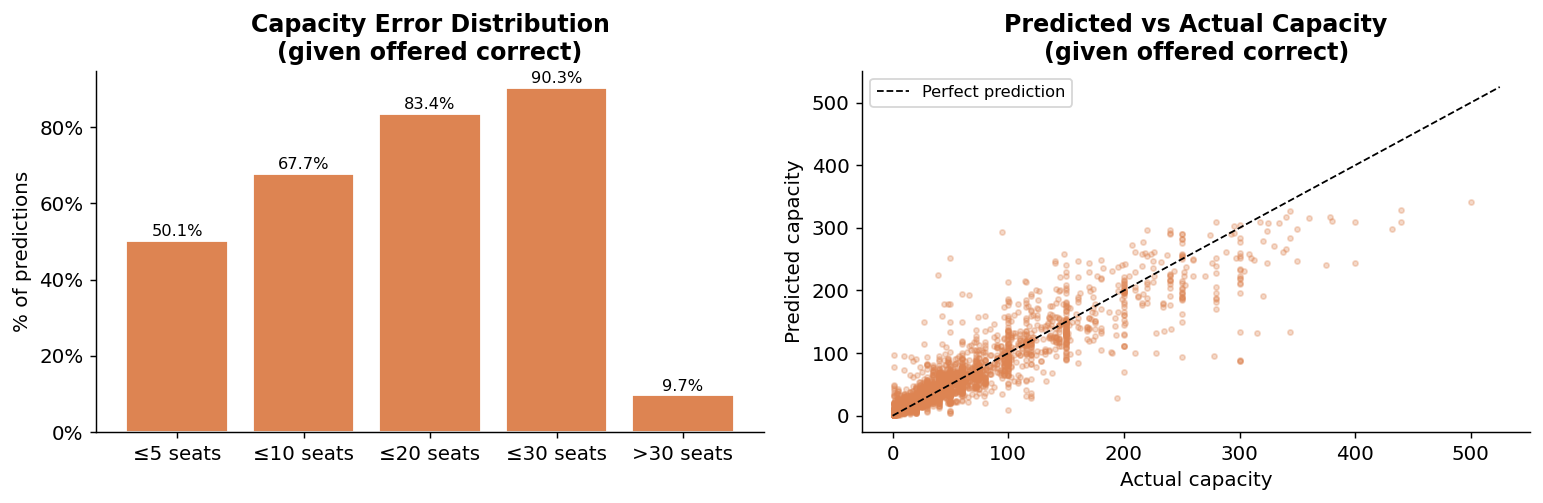

In [10]:
# tolerance buckets for capacity error
cap_err_c1 = (c1['pred_capacity'] - c1['target_capacity']).abs()
buckets_cap = {
    '≤5 seats' : (cap_err_c1 <= 5).mean() * 100,
    '≤10 seats': (cap_err_c1 <= 10).mean() * 100,
    '≤20 seats': (cap_err_c1 <= 20).mean() * 100,
    '≤30 seats': (cap_err_c1 <= 30).mean() * 100,
    '>30 seats' : (cap_err_c1 > 30).mean() * 100,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: error tolerance bars
ax = axes[0]
ax.bar(list(buckets_cap.keys()), list(buckets_cap.values()),
       color=PALETTE['capacity'], edgecolor='white')
for i, (k, v) in enumerate(buckets_cap.items()):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% of predictions')
ax.set_title('Capacity Error Distribution\n(given offered correct)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# right: predicted vs actual scatter
ax2 = axes[1]
ax2.scatter(c1['target_capacity'], c1['pred_capacity'],
            alpha=0.3, s=8, color=PALETTE['capacity'])
lim = max(c1['target_capacity'].max(), c1['pred_capacity'].max()) * 1.05
ax2.plot([0, lim], [0, lim], 'k--', lw=1, label='Perfect prediction')
ax2.set_xlabel('Actual capacity')
ax2.set_ylabel('Predicted capacity')
ax2.set_title('Predicted vs Actual Capacity\n(given offered correct)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / 'C1_capacity_given_offered_correct.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — C1

- When offered is correct, capacity lands within ±10 seats for 67.7% of courses.
- MAE is 12 seats. Bias is +0.7 — the model tends to overpredict.

### C2 — Enrollment given Capacity is Close

Filter to rows where capacity was within tolerance, then evaluate enrollment.
**Question:** When we get the seat count right, does enrollment follow?
Enrollment is bounded by capacity — if capacity is way off, enrollment error compounds.

In [11]:
c2 = fr[fr['correct_capacity'] == 1].copy()
print(f'Rows where capacity is correct: {len(c2):,}  ({len(c2)/len(fr)*100:.1f}% of full rows)')

c2_enr_acc  = c2['correct_enrollment'].mean() * 100
c2_enr_mae  = (c2['pred_enrollment'] - c2['target_enrollment']).abs().mean()
c2_enr_bias = (c2['pred_enrollment'] - c2['target_enrollment']).mean()

print(f'\nEnrollment | given capacity correct:')
print(f'  Within tolerance : {c2_enr_acc:.1f}%')
print(f'  MAE              : {c2_enr_mae:.1f} students')
print(f'  Bias             : {c2_enr_bias:+.1f} students')

Rows where capacity is correct: 3,204  (74.4% of full rows)

Enrollment | given capacity correct:
  Within tolerance : 86.1%
  MAE              : 6.8 students
  Bias             : -0.1 students


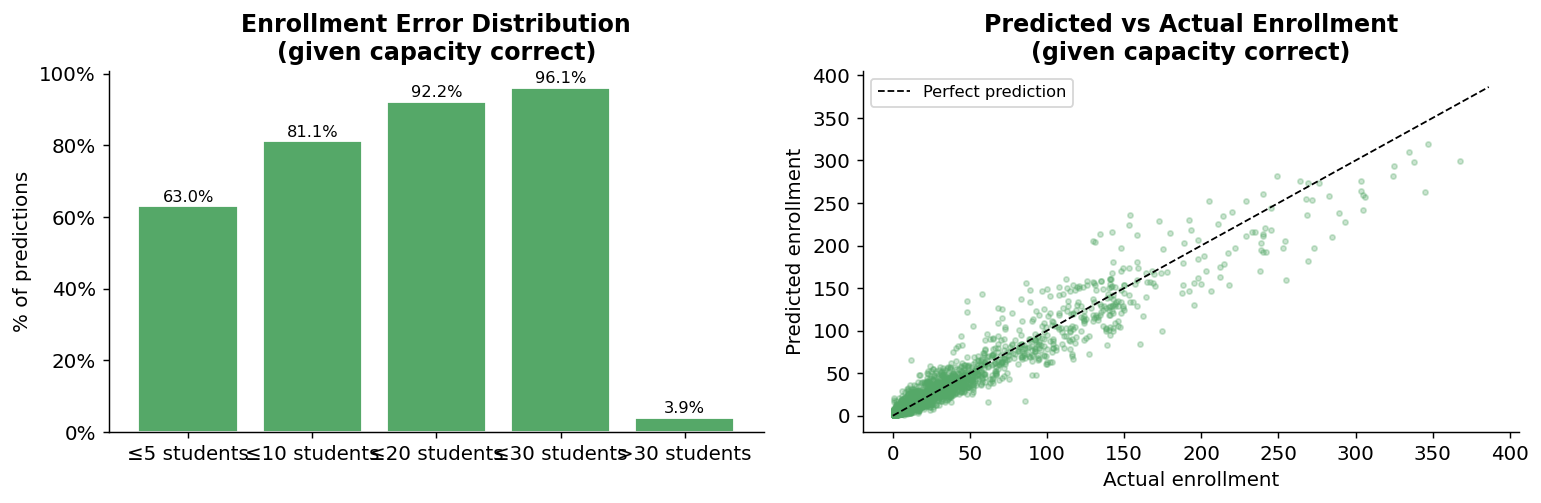

In [12]:
enr_err_c2 = (c2['pred_enrollment'] - c2['target_enrollment']).abs()
buckets_enr = {
    '≤5'  : (enr_err_c2 <= 5).mean() * 100,
    '≤10' : (enr_err_c2 <= 10).mean() * 100,
    '≤20' : (enr_err_c2 <= 20).mean() * 100,
    '≤30' : (enr_err_c2 <= 30).mean() * 100,
    '>30'  : (enr_err_c2 > 30).mean() * 100,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar([f'{k} students' for k in buckets_enr.keys()], list(buckets_enr.values()),
       color=PALETTE['enrollment'], edgecolor='white')
for i, v in enumerate(buckets_enr.values()):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% of predictions')
ax.set_title('Enrollment Error Distribution\n(given capacity correct)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

ax2 = axes[1]
ax2.scatter(c2['target_enrollment'], c2['pred_enrollment'],
            alpha=0.3, s=8, color=PALETTE['enrollment'])
lim2 = max(c2['target_enrollment'].max(), c2['pred_enrollment'].max()) * 1.05
ax2.plot([0, lim2], [0, lim2], 'k--', lw=1, label='Perfect prediction')
ax2.set_xlabel('Actual enrollment')
ax2.set_ylabel('Predicted enrollment')
ax2.set_title('Predicted vs Actual Enrollment\n(given capacity correct)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / 'C2_enrollment_given_capacity_correct.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — C2

- When capacity is correct, enrollment lands within tolerance for 86.1% of courses.
- MAE drops to 6.8 students (vs 12 overall in 05c). Capacity accuracy helpS enrollment.
- Bias: -0.1 students. The model tends to underpredict enrollment even when capacity is right.

### C3 — Enrollment given Offered is Correct

Filter to rows where offered was correct, then evaluate enrollment independently.
**Question:** Does enrollment have its own signal, or does it just follow capacity?
If enrollment accuracy here is similar to C2, it has independent predictive power.

In [13]:
c3 = fr[fr['correct_offered'] == 1].copy()
print(f'Rows where offered is correct: {len(c3):,}')

c3_enr_acc  = c3['correct_enrollment'].mean() * 100
c3_enr_mae  = (c3['pred_enrollment'] - c3['target_enrollment']).abs().mean()
c3_enr_bias = (c3['pred_enrollment'] - c3['target_enrollment']).mean()

print(f'\nEnrollment | given offered correct:')
print(f'  Within tolerance : {c3_enr_acc:.1f}%')
print(f'  MAE              : {c3_enr_mae:.1f} students')
print(f'  Bias             : {c3_enr_bias:+.1f} students')

# comparison table
print('\nEnrollment accuracy comparison:')
enr_unconditional = fr['correct_enrollment'].mean() * 100
print(f'  Unconditional              : {enr_unconditional:.1f}%')
print(f'  Given offered correct (C3) : {c3_enr_acc:.1f}%')
print(f'  Given capacity correct (C2): {c2_enr_acc:.1f}%')

Rows where offered is correct: 4,306

Enrollment | given offered correct:
  Within tolerance : 76.1%
  MAE              : 10.5 students
  Bias             : +0.5 students

Enrollment accuracy comparison:
  Unconditional              : 76.1%
  Given offered correct (C3) : 76.1%
  Given capacity correct (C2): 86.1%


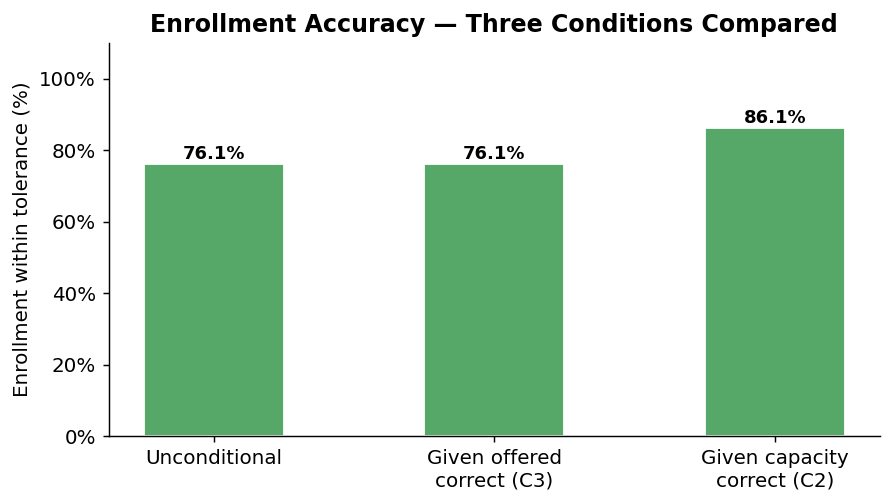

In [14]:
# comparison bar chart — three conditions side by side
conditions = ['Unconditional', 'Given offered\ncorrect (C3)', 'Given capacity\ncorrect (C2)']
enr_accs   = [enr_unconditional, c3_enr_acc, c2_enr_acc]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(conditions, enr_accs, color=PALETTE['enrollment'], edgecolor='white', width=0.5)
for bar, val in zip(bars, enr_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Enrollment within tolerance (%)')
ax.set_title('Enrollment Accuracy — Three Conditions Compared', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig(FIG_PATH / 'C3_enrollment_conditions_compared.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding — C3

- Enrollment accuracy given offered correct: 76.1%. Given capacity correct: 86.1%. Unconditional: 76.1%.
- The gap between C2 and C3 tells us that enrollment largely follows capacity — getting capacity right unlocks enrollment.

---
## Final Summary

The full picture in one view: how the system performs across all three simultaneous predictions.

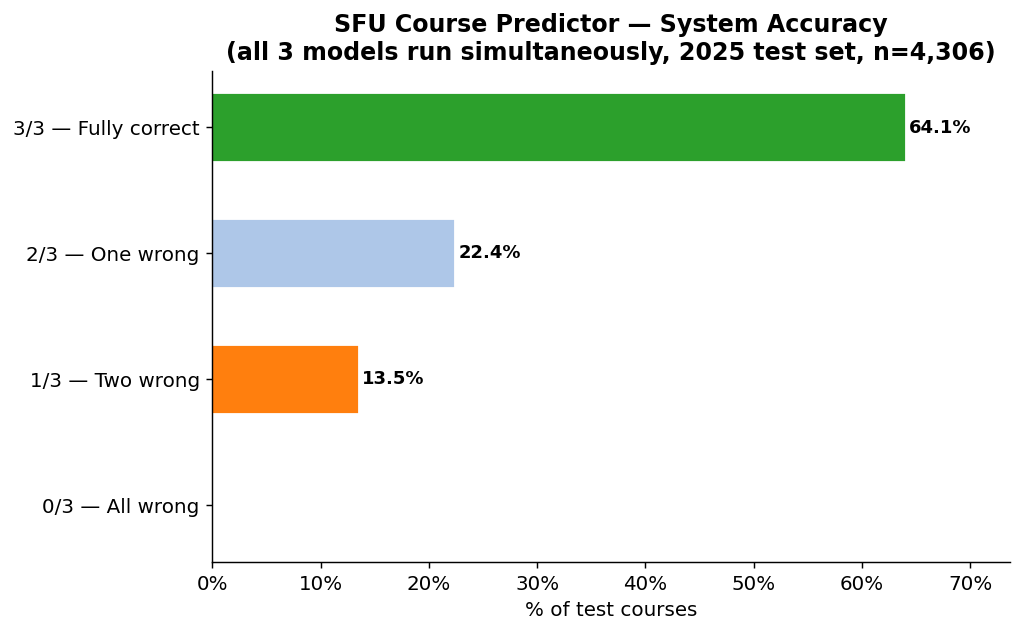

Saved: E_final_system_summary.png 


In [15]:
# ── final summary chart: stacked breakdown ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

score_labels_full = ['0/3 — All wrong', '1/3 — Two wrong', '2/3 — One wrong', '3/3 — Fully correct']
score_vals_full   = [score_pct.get(s, 0) for s in [0, 1, 2, 3]]
bar_colors_full   = ['#d62728', '#ff7f0e', '#aec7e8', '#2ca02c']

bars = ax.barh(score_labels_full, score_vals_full, color=bar_colors_full,
               height=0.55, edgecolor='white')
for bar, val in zip(bars, score_vals_full):
    if val > 1:
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('% of test courses')
ax.set_title(
    'SFU Course Predictor — System Accuracy\n'
    f'(all 3 models run simultaneously, 2025 test set, n={len(fr):,})',
    fontweight='bold'
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, max(score_vals_full) * 1.15)
plt.tight_layout()
plt.savefig(FIG_PATH / 'E_final_system_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: E_final_system_summary.png ')

### Final Finding

**System accuracy: 64.1% of 2025 test courses predicted fully correctly across all three outputs simultaneously.**